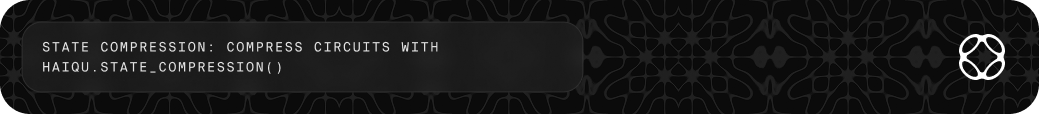

Use `haiqu.state_compression()` to compress quantum circuits and improve performance on noisy quantum hardware.

- For a 10-qubit adder circuit, state compression increases the likelihood of measuring the correct result from 7.7% to 88.8% **(11.5x improvement)**.
- Combining state compression with noise mitigation delivers 99.7% success **(13.0x improvement)**.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.state_compression()`

- **What does it do?** State compression shortens quantum circuits, improving performance on noisy quantum hardware.
- **How do I use it?** Pass a quantum circuit to `haiqu.state_compression()` to create a compression job, then retrieve results with `job.result()`.
- **What are the options?** Optional parameters include `compression_level`, `fine_tuning`, `noise_profile`, and `approximation_level` for advanced configuration.
- **Which option do you recommend?** Start with the default settings for most use cases. For parameter-specific exploration, see dedicated notebooks for `compression_level` and `fine_tuning`.

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and create an adder circuit to demonstrate state compression. The adder circuit adds two integers m and k.

In [1]:
import pandas as pd
import numpy as np
import qiskit

from qiskit.circuit.library import QFTGate

from haiqu.sdk import haiqu

haiqu.login()
haiqu.init("State Compression Tutorial")


def build_adder_circuit(num_qubits, m, k):
    """
    Builds a quantum circuit that adds integer k to m using the QFT.
    
    Parameters:
    - num_qubits (int): Number of qubits.
    - m (int): Initial value.
    - k (int): Value to add.
    
    Returns:
    - QuantumCircuit implementing |m⟩ -> |m + k⟩ with measurement.
    - Binary strings for m and m+k (for verification).
    """
    m_binary = f"{m:0{num_qubits}b}"
    m_plus_k_binary = f"{m + k:0{num_qubits}b}"
    adder = qiskit.QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        if m_binary[i] == "1":
            adder.x(num_qubits - 1 - i)
    adder.compose(QFTGate(num_qubits), inplace=True)
    for i in range(num_qubits):
        adder.rz(k * np.pi / 2 ** i, num_qubits - i - 1)
    adder.compose(QFTGate(num_qubits).inverse(), inplace=True)
    adder.measure_all()
    return adder, m_binary, m_plus_k_binary


adder, m_binary, m_plus_k_binary = build_adder_circuit(num_qubits=10, m=343, k=19)
haiqu.draw(adder)

## Run benchmark scenarios

Run experiments comparing original circuit, compressed circuit, and compressed circuit with mitigation on a noisy device:

In [2]:
scenarios = [
    {"compression": False, "mitigation": False, "description": "Original Circuit"},
    {"compression": True,  "mitigation": False, "description": "With Compression"},
    {"compression": True,  "mitigation": True,  "description": "With Compression + Mitigation"}
]

### Submit Jobs

In [3]:
# Submit jobs and save job IDs
saved_job_ids = {}
for scenario in scenarios:
    circuit = adder

    # Apply state compression to circuit if requested
    if scenario["compression"]:
        job_h = haiqu.state_compression(circuit=circuit)
        circuit = job_h.result()
    
    # Run circuit on noisy device with optional mitigation
    job = haiqu.run(circuit, shots=1000, device_id="fake_montreal", use_mitigation=scenario["mitigation"])
    saved_job_ids[scenario["description"]] = job.id
    print(f"{scenario['description']}: {job.id}")

Original Circuit: jb-799fc7c9-a178-41cd-b861-028efeb9f258
With Compression: jb-a60e6baa-7b0a-4c80-97e9-5312824eae2e
With Compression + Mitigation: jb-ecefc658-7bd8-4232-ac5a-0a58463edcca


### Retrieve Results
Run this cell once jobs are complete. For real QPU jobs, this may take minutes to hours. You can close the notebook and come back later—just use the saved job IDs to retrieve results in a new session.

**Note:** `job.result()` is a blocking call. If the job is not complete, it will wait until results are ready.

In [4]:
# Retrieve results from saved job IDs
results = []
for name, job_id in saved_job_ids.items():
    job = haiqu.get_job(job_id)
    print(f"{name}: {job.retrieve_status()}")
    res = job.result()
    prob = res[0].get(m_plus_k_binary, 0)
    results.append({"probability": prob, "description": name})

Original Circuit: JobStatus.DONE
With Compression: JobStatus.DONE
With Compression + Mitigation: JobStatus.RUNNING


State compression significantly improves circuit performance on noisy devices. Summary of results:

In [5]:
def build_summary(results):
    """Build summary table data from experiment results."""
    baseline = results[0]["probability"]
    return {
        'Configuration': [r["description"] for r in results],
        'Success Probability': [f'{r["probability"]:.1%}' for r in results],
        'Improvement': ['Baseline'] + [f'{(r["probability"]/baseline):.1f}x' for r in results[1:]],
        'Business Impact': [
            'Low success rate on noisy hardware',
            'Significant improvement enables practical quantum algorithms',
            'Near-perfect results make production deployment viable',
        ]
    }

pd.set_option('display.max_colwidth', None)
pd.DataFrame(build_summary(results))

,Configuration,Success Probability,Improvement,Business Impact
0,Original Circuit,7.6%,Baseline,Low success rate on noisy hardware
1,With Compression,88.1%,11.6x,Significant improvement enables practical quantum algorithms
2,With Compression + Mitigation,100.0%,13.2x,Near-perfect results make production deployment viable


> **🎲 Note:** Due to the stochastic nature of quantum sampling, these results will differ slightly between runs.

> **💡 Good to Know:** [Compression techniques](https://docs.haiqu.ai/core_features/compression) can be combined with [noise mitigation techniques](https://docs.haiqu.ai/core_features/error_shield).

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

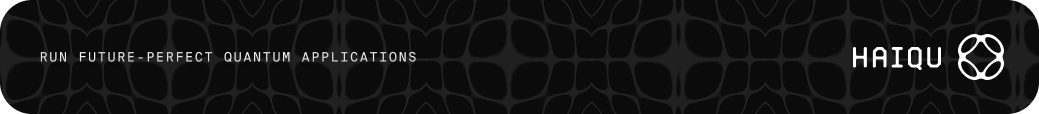